In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Generar dataset 2D visualizable
X, y = make_classification(n_samples=500, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1,
                           class_sep=1.0, flip_y=0.1,
                           random_state=42)

# 2. Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Estandarizar
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

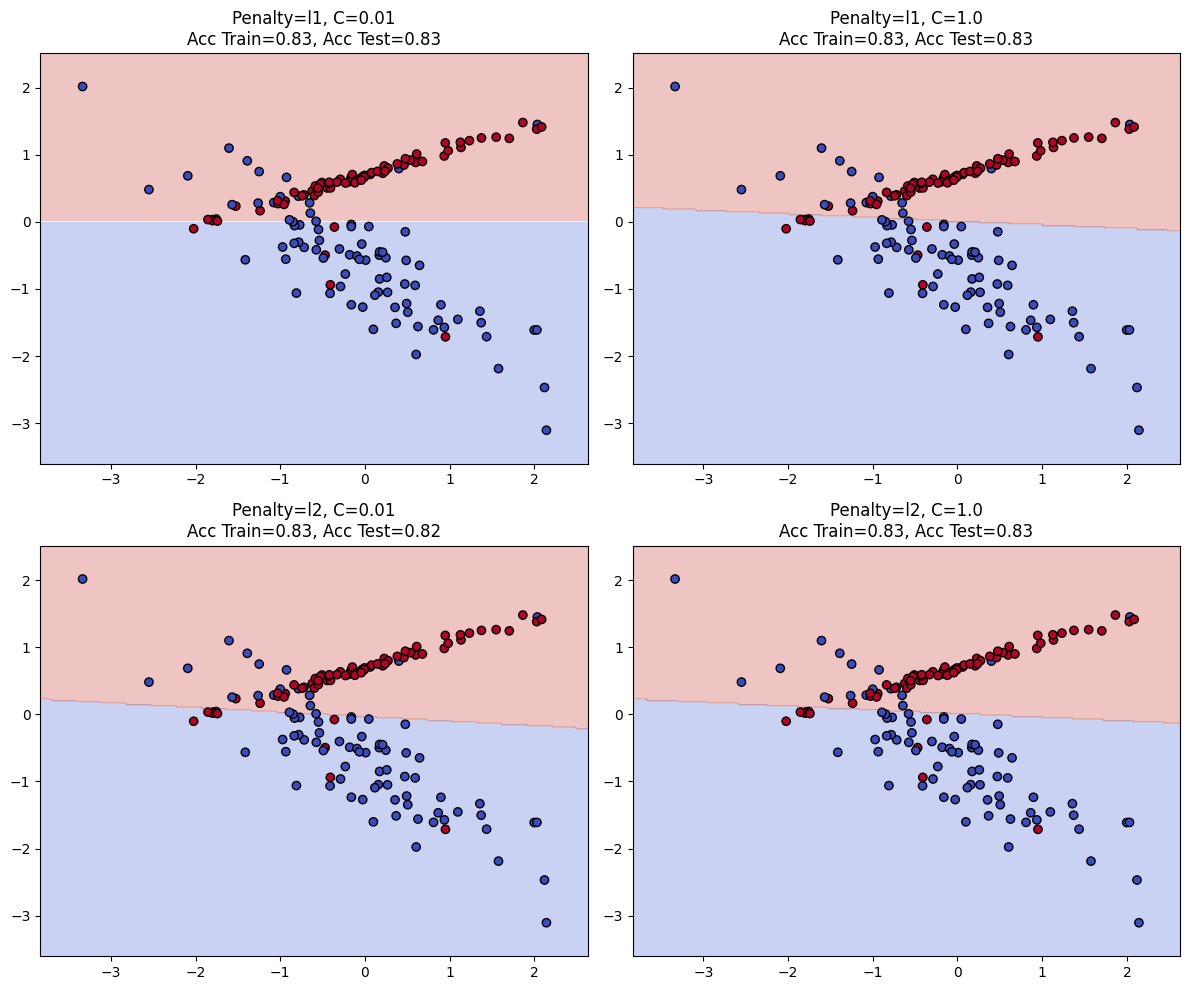

In [2]:

# 4. Probar diferentes configuraciones
configs = [
    {"penalty": "l1", "dual": False, "C": 0.01},
    {"penalty": "l1", "dual": False, "C": 1.0},
    {"penalty": "l2", "dual": True, "C": 0.01},
    {"penalty": "l2", "dual": True, "C": 1.0}
]

# 5. Visualización
def plot_decision_boundary(model, X, y, ax, title):
    # Malla
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)

# 6. Entrenamiento y visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, config in enumerate(configs):
    clf = LinearSVC(penalty=config["penalty"],
                    dual=config["dual"],
                    C=config["C"],
                    max_iter=10000)
    clf.fit(X_train_std, y_train)
    y_train_pred = clf.predict(X_train_std)
    y_test_pred = clf.predict(X_test_std)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    title = f'Penalty={config["penalty"]}, C={config["C"]}\nAcc Train={acc_train:.2f}, Acc Test={acc_test:.2f}'
    plot_decision_boundary(clf, X_test_std, y_test, axes[i], title)

plt.tight_layout()
plt.show()

In [3]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Pipeline con escalado y modelo
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(penalty="l1", dual=False, max_iter=10000))
])

# Rango de C a explorar
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Búsqueda con validación cruzada
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

# Resultados
print(f"Mejor valor de C: {grid.best_params_['clf__C']}")
print(f"Mejor score de validación cruzada: {grid.best_score_:.4f}")

# Evaluar en test
y_pred = grid.predict(X_test)
print("Rendimiento en test:")
print(classification_report(y_test, y_pred))

Mejor valor de C: 0.01
Mejor score de validación cruzada: 0.8343
Rendimiento en test:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        81
           1       0.76      0.93      0.84        69

    accuracy                           0.83       150
   macro avg       0.84      0.84      0.83       150
weighted avg       0.85      0.83      0.83       150



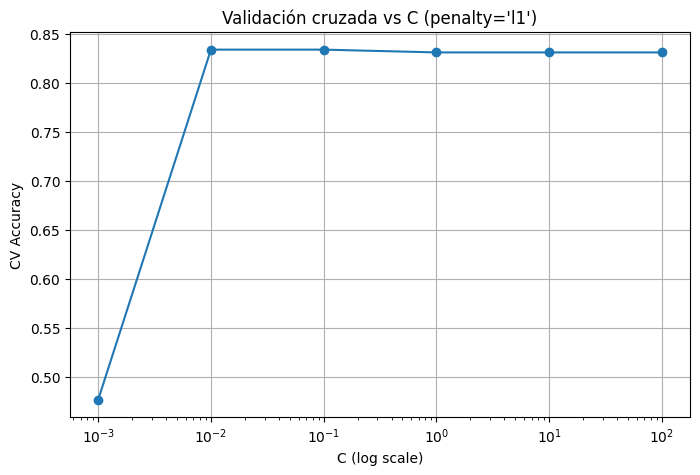

In [4]:
import matplotlib.pyplot as plt

mean_scores = grid.cv_results_["mean_test_score"]
C_values = param_grid["clf__C"]

plt.figure(figsize=(8,5))
plt.plot(C_values, mean_scores, marker='o')
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.title("Validación cruzada vs C (penalty='l1')")
plt.grid(True)
plt.show()

Coeficientes del modelo:
[[0.         0.54412904]]
Coeficientes planos: [0.         0.54412904]
Intercepto: [0.]


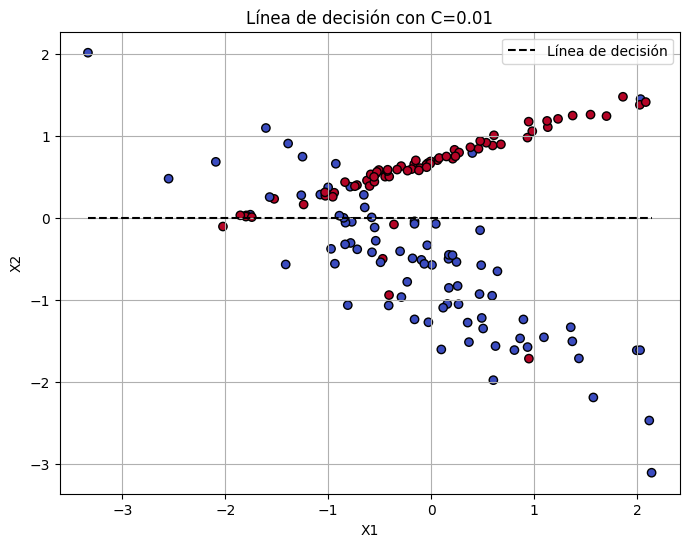

In [5]:
# Mejor modelo completo (Pipeline)
best_model = grid.best_estimator_

# Acceder al clasificador LinearSVC entrenado
best_clf = best_model.named_steps["clf"]

# Obtener coeficientes
print("Coeficientes del modelo:")
print(best_clf.coef_)

# Si quieres los coeficientes planos (para 2D):
print("Coeficientes planos:", best_clf.coef_.ravel())
print("Intercepto:", best_clf.intercept_)

w = best_clf.coef_[0]
b = best_clf.intercept_[0]

# Crear línea de decisión: w0 * x + w1 * y + b = 0 ⇒ y = -(w0*x + b)/w1
x_vals = np.linspace(X_test_std[:, 0].min(), X_test_std[:, 0].max(), 100)
y_vals = -(w[0] * x_vals + b) / w[1]

# Graficar
plt.figure(figsize=(8, 6))
plt.scatter(X_test_std[:, 0], X_test_std[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k')
plt.plot(x_vals, y_vals, 'k--', label="Línea de decisión")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title(f"Línea de decisión con C={grid.best_params_['clf__C']}")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Pipeline con escalado + modelo SVC lineal
pipeline_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", max_iter=10000))
])

# Grid de búsqueda: valores de C
param_grid_svc = {
    "svc__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

# GridSearchCV
grid_svc = GridSearchCV(pipeline_svc, param_grid_svc, cv=5, scoring="accuracy", n_jobs=-1)
grid_svc.fit(X_train, y_train)

# Resultados
print(f"Mejor valor de C: {grid_svc.best_params_['svc__C']}")
print(f"Mejor score de validación cruzada: {grid_svc.best_score_:.4f}")

# Evaluación en test
y_pred_svc = grid_svc.predict(X_test)
print("Evaluación en test:")
print(classification_report(y_test, y_pred_svc))

Mejor valor de C: 10
Mejor score de validación cruzada: 0.8429
Evaluación en test:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82        81
           1       0.75      0.94      0.83        69

    accuracy                           0.83       150
   macro avg       0.84      0.84      0.83       150
weighted avg       0.85      0.83      0.83       150



In [8]:
best_svc = grid_svc.best_estimator_.named_steps["svc"]

print("Coeficientes del mejor modelo SVC:")
print(best_svc.coef_.ravel())
print("Intercepto:", best_svc.intercept_)

Coeficientes del mejor modelo SVC:
[-0.55877335  1.79406164]
Intercepto: [-0.18431771]


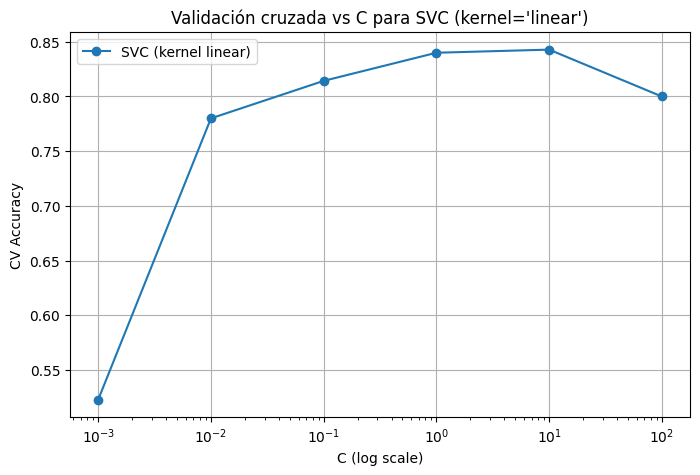

In [9]:
import matplotlib.pyplot as plt

mean_scores_svc = grid_svc.cv_results_["mean_test_score"]
C_values = param_grid_svc["svc__C"]

plt.figure(figsize=(8,5))
plt.plot(C_values, mean_scores_svc, marker='o', label='SVC (kernel linear)')
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV Accuracy")
plt.title("Validación cruzada vs C para SVC (kernel='linear')")
plt.grid(True)
plt.legend()
plt.show()

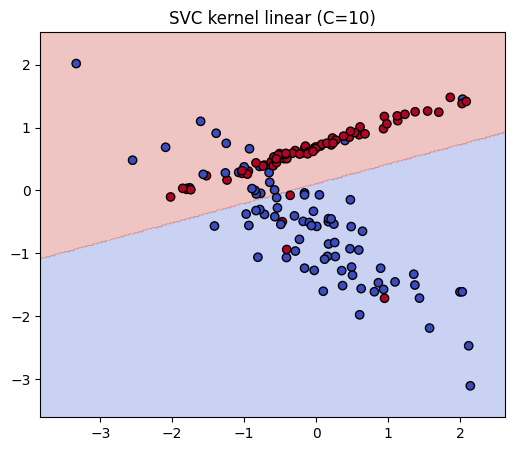

Coeficientes (svc): [-0.55877335  1.79406164]
Intercepto: [-0.18431771]


In [10]:
# Extraer mejor modelo del pipeline (ya está entrenado)
best_pipeline = grid_svc.best_estimator_
best_scaler = best_pipeline.named_steps["scaler"]
best_model = best_pipeline.named_steps["svc"]

# Escalar X_test con el mismo scaler
X_test_std = best_scaler.transform(X_test)

# Dibujar frontera con la misma función
fig, ax = plt.subplots(figsize=(6, 5))
plot_decision_boundary(best_model, X_test_std, y_test, ax,
                       f'SVC kernel linear (C={grid_svc.best_params_["svc__C"]})')
plt.show()

# Mostrar coeficientes e intercepto
print("Coeficientes (svc):", best_model.coef_.ravel())
print("Intercepto:", best_model.intercept_)

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sun Apr 16 00:34:36 2023

@author: dagom EJEMPLO DEL BANCO !!!!!!
"""
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import string
import re

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
#style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords

## smote and similar
from imblearn.over_sampling import SMOTE
#from imblearn.under_sampling import Tomelinks

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## LECTURA DE DATOS

bank=pd.read_csv('bank-full.csv', sep=';')

variables=bank.columns
print(variables)

X=bank.iloc[:,0:16]
y=pd.DataFrame(bank["y"])

y.describe()
y.value_counts()
## clase del no 39922/45211 ## muy balanceado

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


,count
y,
no,39922
yes,5289


In [ ]:
display(bank.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
## Paso 1. vemos cuantos missing tenemos en cada variable ##
bank.isnull().sum()

# Paso 2. Para poder aplicar SVM las variables deben ser numericas y a ser posibles estandarizadas
from sklearn import preprocessing

col_cat = bank[['job', 'marital','education','default', 'housing','loan','contact','y']]
col_num = bank[['age', 'balance', 'day','duration','pdays','previous']]


scaler = preprocessing.StandardScaler().fit(col_num)
col_num_standarizada = scaler.transform(col_num)

col_num_standarizada.mean(axis=0)
col_num_standarizada.std(axis=0)

col_num_standarizada = pd.DataFrame(col_num_standarizada)


bank_depurada = pd.concat([col_num_standarizada, col_cat],  axis=1) ## aunque asi se pierden los nombres de las variables

## recuperamos los nombres y tenemos  nuestra base de datos depurada
bank_depurada=bank_depurada.set_axis(['age', 'balance', 'day' ,'duration','pdays','previous' , 'job', 'marital','education','default', 'housing','loan','contact','y'], axis=1)


## Paso 3. Variables categoricas las pasamos a dummies

bank_depurada_dummies = pd.get_dummies(bank_depurada,columns=['job', 'marital','education','default', 'housing','loan','contact','y'], drop_first= True)
bank_depurada_dummies.head()


X=bank_depurada_dummies.iloc[:,0:26]
y=pd.DataFrame(bank_depurada_dummies["y_yes"])

y.describe()
y.value_counts()


########### hacemos clasificacion con SVM ####
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)


###

# train the model on train set
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# print prediction results
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
print(cm)  ## ojo a esta matriz de confusion !!!!!
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)

              precision    recall  f1-score   support

       False       0.88      1.00      0.94     11967
        True       0.00      0.00      0.00      1597

    accuracy                           0.88     13564
   macro avg       0.44      0.50      0.47     13564
weighted avg       0.78      0.88      0.83     13564

[[11967     0]
 [ 1597     0]]
accuracy 0.882261869654969


In [ ]:
#############################
################## smooooote
#############################




## busqueda de parametros para el caso lineal ###
from sklearn.model_selection import GridSearchCV

# definimos los rangos de los parametros
param_grid_lineal = {'C': [0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 5, 10, 100, 1000] }
grid = GridSearchCV(SVC(kernel='linear'), param_grid_lineal, refit = True, cv=5, verbose = 3)

# ENTRENAMOS EN TRAIN Y BUSCAMOS EN TRAIN
resultados = grid.fit(X_train, y_train)

#############################

grid_predictions = grid.predict(X_test)

# print classification report
print(classification_report(y_test, grid_predictions))
cm = confusion_matrix(y_test, grid_predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)


Fitting 5 folds for each of 11 candidates, totalling 55 fits
[CV 1/5] END .............................C=0.1;, score=0.883 total time=   9.9s
[CV 2/5] END .............................C=0.1;, score=0.883 total time=   8.2s
[CV 3/5] END .............................C=0.1;, score=0.883 total time=  10.0s
[CV 4/5] END .............................C=0.1;, score=0.883 total time=  10.4s
[CV 5/5] END .............................C=0.1;, score=0.883 total time=   8.3s
[CV 1/5] END .............................C=0.2;, score=0.883 total time=  10.9s
[CV 2/5] END .............................C=0.2;, score=0.883 total time=  10.5s
[CV 3/5] END .............................C=0.2;, score=0.883 total time=   9.7s
[CV 4/5] END .............................C=0.2;, score=0.883 total time=  11.4s
[CV 5/5] END .............................C=0.2;, score=0.883 total time=  10.7s
[CV 1/5] END .............................C=0.3;, score=0.883 total time=  11.5s
[CV 2/5] END .............................C=0.3;

In [ ]:


from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X_train, y_train)


y_res.describe()
y_res.value_counts()




,count
y_yes,
False,27955
True,27955


In [ ]:

model = SVC(kernel='linear')
model.fit(X_res, y_res)

# print prediction results
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
print(cm)
accuracy=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])
print('accuracy' , accuracy)



              precision    recall  f1-score   support

       False       0.96      0.81      0.88     11967
        True       0.35      0.75      0.47      1597

    accuracy                           0.80     13564
   macro avg       0.65      0.78      0.68     13564
weighted avg       0.89      0.80      0.83     13564

[[9687 2280]
 [ 393 1204]]
accuracy 0.8029342376879977
